<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/2015_Flight_Delays_and_Cancellations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# Aviation — U.S. Flight Delay Network Analysis
# Full Google Colab Solution
# ============================================================

# CELL 1 — Imports
# ──────────────────────────────────────────────────────

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import networkx as nx
import warnings
import kagglehub
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

# CELL 2 — Stage 1: Data Ingestion
# ──────────────────────────────────────────────────────

In [ ]:
# Download latest version
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-delays' dataset.
Path to dataset files: /kaggle/input/flight-delays


In [ ]:
url1 = path + "/airlines.csv"
url2 = path + '/airports.csv'
url3 = path + '/flights.csv'

airlines_df = pd.read_csv(url1)
airports_df = pd.read_csv(url2)
flights_df = pd.read_csv(url3)

In [ ]:
airlines_df.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [ ]:
airlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes


In [ ]:
airlines_df.shape

(14, 2)

In [ ]:
airports_df.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [ ]:
airports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB


In [ ]:
airports_df.shape

(322, 7)

In [ ]:
flights_df.head(10000)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2015,1,1,4,HA,165,N492HA,OGG,HNL,1705,...,1757.0,17.0,0,0,NaN,0.0,0.0,7.0,10.0,0.0
9996,2015,1,1,4,MQ,3046,N610MQ,DBQ,ORD,1705,...,1743.0,-32.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9997,2015,1,1,4,MQ,3048,N679MQ,ORD,CMI,1705,...,1814.0,26.0,0,0,NaN,10.0,0.0,5.0,11.0,0.0
9998,2015,1,1,4,MQ,3118,N512MQ,MDT,ORD,1705,...,2131.0,196.0,0,0,NaN,21.0,0.0,112.0,63.0,0.0


In [ ]:
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [ ]:
flights_df.shape

(5819079, 31)

In [ ]:
print("\n📥 Stage 1: Ingesting data...")

path = kagglehub.dataset_download("usdot/flight-delays")
print("Dataset path:", path)

# Define dtypes to reduce RAM usage (float64 → float32, int64 → int16/int8)
dtype_map = {
    "YEAR":                 "int16",
    "MONTH":                "int8",
    "DAY":                  "int8",
    "DAY_OF_WEEK":          "int8",
    "FLIGHT_NUMBER":        "int32",
    "SCHEDULED_DEPARTURE":  "int32",
    "DEPARTURE_TIME":       "float32",
    "DEPARTURE_DELAY":      "float32",
    "ARRIVAL_DELAY":        "float32",
    "DISTANCE":             "int32",
    "CANCELLED":            "int8",
    "DIVERTED":             "int8",
}

usecols = [
    "MONTH", "DAY_OF_WEEK",
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
    "DEPARTURE_DELAY", "ARRIVAL_DELAY",
    "FLIGHT_NUMBER",
    "CANCELLED", "DIVERTED",
]

flights_raw = pd.read_csv(
    f"{path}/flights.csv",
    usecols=usecols,
    dtype={k: v for k, v in dtype_map.items() if k in usecols},
    low_memory=False,
)

airlines_df = pd.read_csv(f"{path}/airlines.csv")
airports_df = pd.read_csv(f"{path}/airports.csv")

print(f"  Raw flights shape : {flights_raw.shape}")
print(f"  Airlines          : {airlines_df.shape}")
print(f"  Airports          : {airports_df.shape}")
print("✅ Ingestion complete.\n")


📥 Stage 1: Ingesting data...
Using Colab cache for faster access to the 'flight-delays' dataset.
Dataset path: /kaggle/input/flight-delays
  Raw flights shape : (5819079, 9)
  Airlines          : (14, 2)
  Airports          : (322, 7)
✅ Ingestion complete.



# CELL 3 — Stage 2: Data Cleaning
# ──────────────────────────────────────────────────────

In [ ]:
print("🧹 Stage 2: Cleaning data...")

df = flights_raw.copy()

# 1. Remove cancelled and diverted flights
before = len(df)
df = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)]
print(f"  Dropped cancelled/diverted : {before - len(df):,} rows")

# 2. Drop rows with missing delay values
before = len(df)
df = df.dropna(subset=["DEPARTURE_DELAY", "ARRIVAL_DELAY",
                        "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"])
print(f"  Dropped missing delays     : {before - len(df):,} rows")

# 3. Keep only IATA-code airports (3 uppercase letters — drop numeric codes)
mask = (
    df["ORIGIN_AIRPORT"].str.len().eq(3) &
    df["DESTINATION_AIRPORT"].str.len().eq(3)
)
before = len(df)
df = df[mask]
print(f"  Dropped non-IATA airports  : {before - len(df):,} rows")

# 4. Remove duplicate records
before = len(df)
df = df.drop_duplicates()
print(f"  Dropped duplicates         : {before - len(df):,} rows")

# 5. Drop helper columns no longer needed
df = df.drop(columns=["CANCELLED", "DIVERTED", "FLIGHT_NUMBER"])

print(f"\n  ✅ Clean dataset shape     : {df.shape}")
print(df.dtypes)

🧹 Stage 2: Cleaning data...
  Dropped cancelled/diverted : 105,071 rows
  Dropped missing delays     : 0 rows
  Dropped non-IATA airports  : 482,878 rows
  Dropped duplicates         : 15,457 rows

  ✅ Clean dataset shape     : (5215673, 6)
MONTH                     int8
DAY_OF_WEEK               int8
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
DEPARTURE_DELAY        float32
ARRIVAL_DELAY          float32
dtype: object


# CELL 4 — Stage 3: Graph Analysis
# ──────────────────────────────────────────────────────

In [ ]:
print("\n🔬 Stage 3: Building delay propagation network...")

# Filter for significantly delayed departures (>15 min threshold)
delayed = df[df["DEPARTURE_DELAY"] > 15].copy()
print(f"  Flights with departure delay >15 min : {len(delayed):,}")

# Aggregate to route level: sum of ARRIVAL_DELAY per (origin → destination)
route_delay = (
    delayed
    .groupby(["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"], as_index=False)
    ["ARRIVAL_DELAY"]
    .sum()
    .rename(columns={"ARRIVAL_DELAY": "DELAY_VOLUME"})
)
route_delay = route_delay[route_delay["DELAY_VOLUME"] > 0]
print(f"  Unique routes with positive delay volume : {len(route_delay):,}")

# Build Directed Weighted Graph
G = nx.DiGraph()

for _, row in route_delay.iterrows():
    G.add_edge(
        row["ORIGIN_AIRPORT"],
        row["DESTINATION_AIRPORT"],
        weight=row["DELAY_VOLUME"],
    )

print(f"  Graph nodes (airports) : {G.number_of_nodes()}")
print(f"  Graph edges (routes)   : {G.number_of_edges()}")

# Weighted Out-Strength Centrality
# = sum of outgoing edge weights = total delay minutes propagated outward
out_strength = dict(G.out_degree(weight="weight"))

# Verify against NetworkX's method (sanity check)
assert out_strength == dict(G.out_degree(weight="weight")), \
    "❌ Out-strength mismatch!"

# Rank airports
strength_series = (
    pd.Series(out_strength, name="OUT_STRENGTH")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "AIRPORT"})
)

top5 = strength_series.head(5)
print("\n🏆 Top 5 Super-Spreader Airports:")
print(top5.to_string(index=False))

# Merge with airport names for labels
top5 = top5.merge(
    airports_df[["IATA_CODE", "AIRPORT", "CITY", "STATE"]],
    left_on="AIRPORT", right_on="IATA_CODE", how="left"
).rename(columns={"AIRPORT_x": "IATA", "AIRPORT_y": "AIRPORT_NAME"})


🔬 Stage 3: Building delay propagation network...
  Flights with departure delay >15 min : 953,974
  Unique routes with positive delay volume : 4,566
  Graph nodes (airports) : 322
  Graph edges (routes)   : 4566

🏆 Top 5 Super-Spreader Airports:
AIRPORT  OUT_STRENGTH
    ORD     3867366.0
    ATL     3007594.0
    DFW     2700912.0
    DEN     2230294.0
    LAX     2003532.0


# CELL 5 — Stage 4a: Bar Chart — Top 5 Super-Spreader Airports
# ──────────────────────────────────────────────────────


📊 Visualization 1: Top 5 Bar Chart


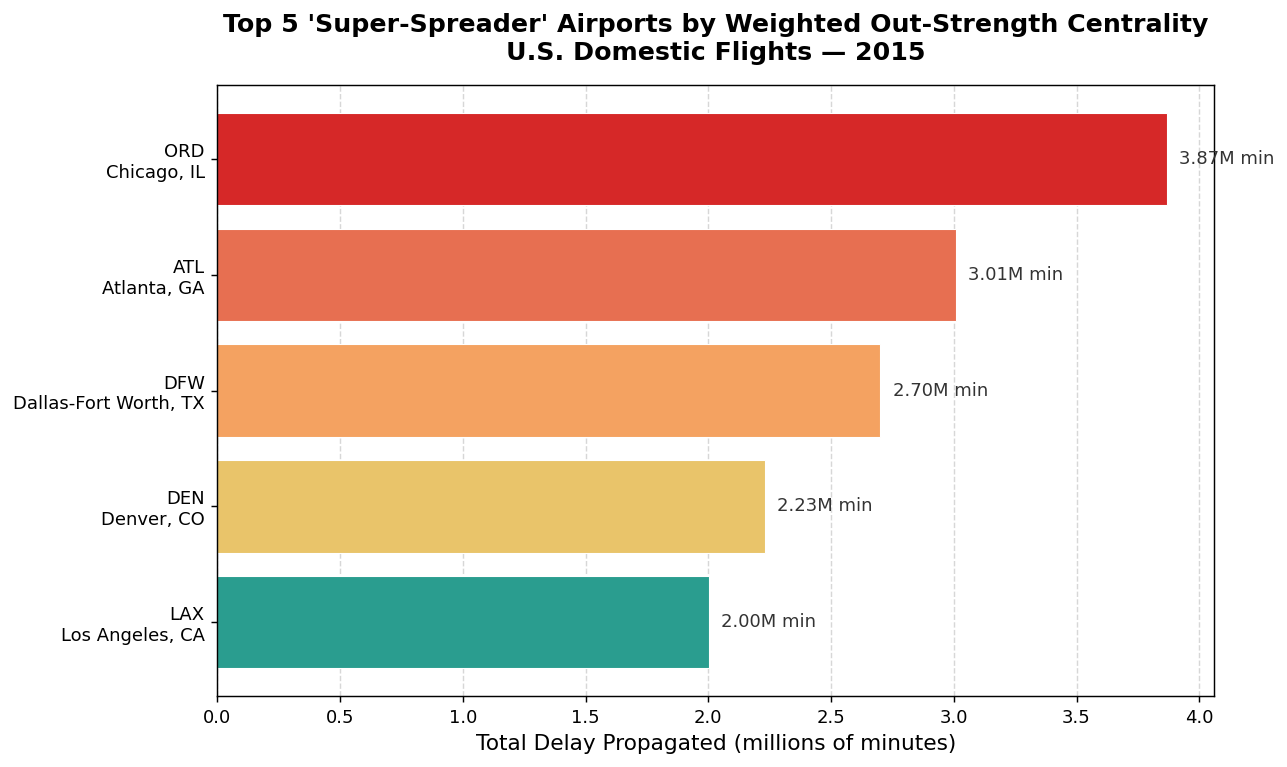

  Saved → top5_superspreaders.png


In [ ]:
print("\n📊 Visualization 1: Top 5 Bar Chart")

palette = ["#D62828", "#E76F51", "#F4A261", "#E9C46A", "#2A9D8F"]
labels = [
    f"{row['IATA']}\n{row['CITY']}, {row['STATE']}"
    for _, row in top5.iterrows()
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    labels[::-1],
    top5["OUT_STRENGTH"].values[::-1] / 1e6,
    color=palette[::-1],
    edgecolor="white", linewidth=0.6,
)

ax.set_xlabel("Total Delay Propagated (millions of minutes)", fontsize=12)
ax.set_title(
    "Top 5 'Super-Spreader' Airports by Weighted Out-Strength Centrality\n"
    "U.S. Domestic Flights — 2015",
    fontsize=14, fontweight="bold", pad=14,
)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, top5["OUT_STRENGTH"].values[::-1]):
    ax.text(
        bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val/1e6:.2f}M min",
        va="center", fontsize=10, color="#333",
    )

plt.tight_layout()
plt.savefig("top5_superspreaders.png", bbox_inches="tight")
plt.show()
print("  Saved → top5_superspreaders.png")

# CELL 6 — Stage 4b: Network Graph — Delay Propagation
# ──────────────────────────────────────────────────────


🌐 Visualization 2: Network Graph


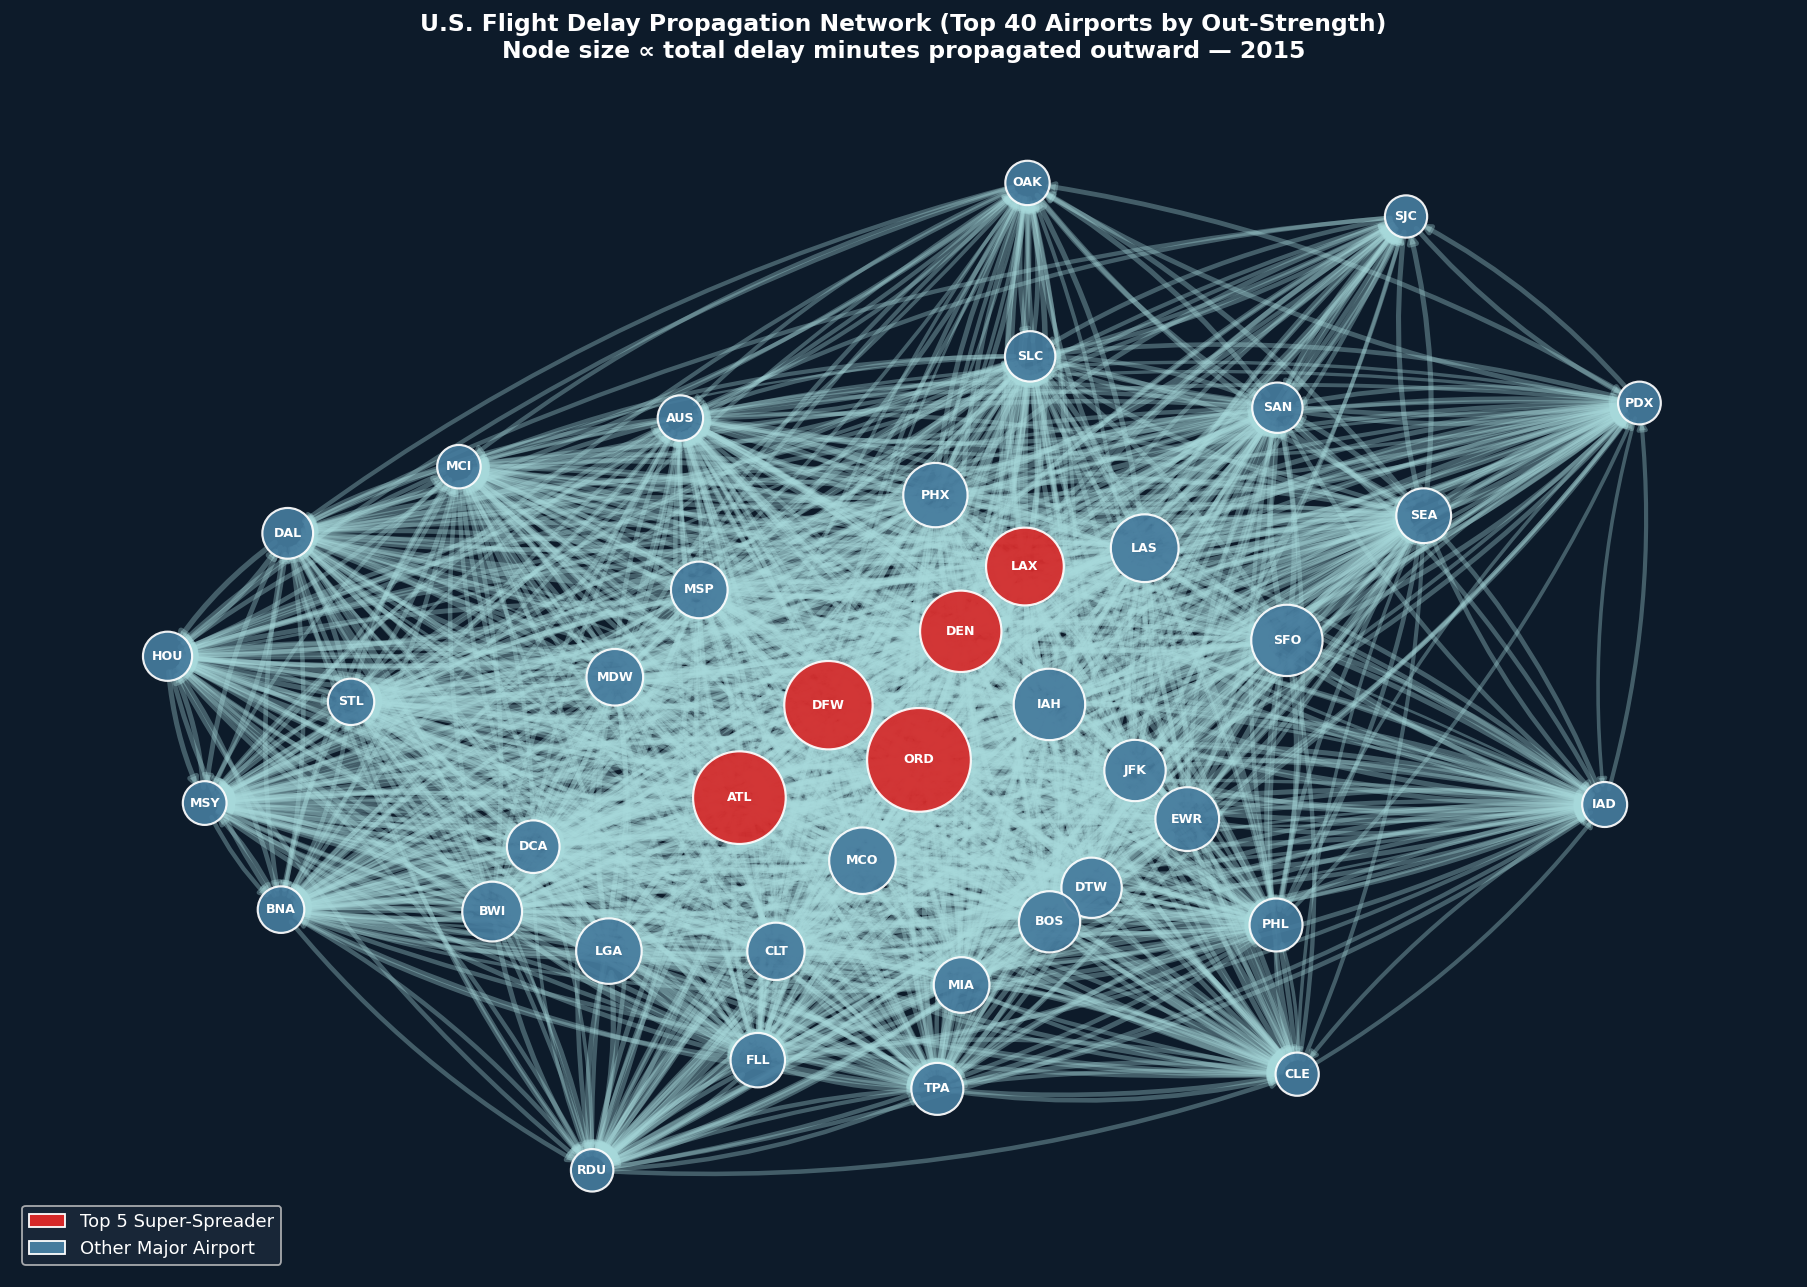

  Saved → delay_network_graph.png


In [ ]:
print("\n🌐 Visualization 2: Network Graph")

TOP_N_NODES = 40   # keep graph readable
top_airports = strength_series.head(TOP_N_NODES)["AIRPORT"].tolist()
top5_set = set(top5["IATA"].tolist())

subG = G.subgraph(top_airports).copy()

# Layout
pos = nx.spring_layout(subG, seed=42, k=2.5)

# Node sizes proportional to out-strength
node_strengths = np.array([
    out_strength.get(n, 0) for n in subG.nodes()
])
node_sizes = 300 + (node_strengths / node_strengths.max()) * 3000
node_colors = [
    "#D62828" if n in top5_set else "#457B9D"
    for n in subG.nodes()
]

# Edge widths proportional to weight (log-scaled for readability)
edge_weights = np.array([
    subG[u][v]["weight"] for u, v in subG.edges()
])
edge_widths = 0.3 + 3 * (np.log1p(edge_weights) / np.log1p(edge_weights.max()))

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#0D1B2A")
fig.patch.set_facecolor("#0D1B2A")

nx.draw_networkx_edges(
    subG, pos, ax=ax,
    width=edge_widths, alpha=0.35,
    edge_color="#A8DADC", arrows=True,
    arrowsize=10, connectionstyle="arc3,rad=0.1",
)
nx.draw_networkx_nodes(
    subG, pos, ax=ax,
    node_size=node_sizes,
    node_color=node_colors, alpha=0.92,
    linewidths=1.2, edgecolors="white",
)
nx.draw_networkx_labels(
    subG, pos, ax=ax,
    font_size=7, font_color="white", font_weight="bold",
)

legend_elements = [
    mpatches.Patch(facecolor="#D62828", edgecolor="white",
                   label="Top 5 Super-Spreader"),
    mpatches.Patch(facecolor="#457B9D", edgecolor="white",
                   label="Other Major Airport"),
]
ax.legend(handles=legend_elements, loc="lower left",
          facecolor="#1B2A3B", labelcolor="white", fontsize=10)

ax.set_title(
    "U.S. Flight Delay Propagation Network (Top 40 Airports by Out-Strength)\n"
    "Node size ∝ total delay minutes propagated outward — 2015",
    color="white", fontsize=13, fontweight="bold", pad=12,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("delay_network_graph.png", bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("  Saved → delay_network_graph.png")

##3D Interactive Network Graph (Plotly)

In [ ]:
import plotly.graph_objects as go
import numpy as np
import networkx as nx

print("🌐 3D Interactive Network Graph yasalmoqda...")

# ── 1. Subgraph tayyorlash (top 40 airport) ──────────────────
TOP_N_NODES = 40
top_airports = strength_series.head(TOP_N_NODES)["AIRPORT"].tolist()
top5_set = set(top5["IATA"].tolist())
subG = G.subgraph(top_airports).copy()

# ── 2. 3D layout (spring layout + z-koordinata) ──────────────
pos_2d = nx.spring_layout(subG, seed=42, k=2.2)

# Z o'qi = out-strength qiymatiga proporsional (balandlik = ta'sir kuchi)
max_strength = max(out_strength.values())
pos_3d = {
    node: (
        pos_2d[node][0],
        pos_2d[node][1],
        out_strength.get(node, 0) / max_strength * 3   # Z: 0..3 oralig'ida
    )
    for node in subG.nodes()
}

# ── 3. Edge chiziqlarini tayyorlash ──────────────────────────
edge_x, edge_y, edge_z = [], [], []

for u, v in subG.edges():
    x0, y0, z0 = pos_3d[u]
    x1, y1, z1 = pos_3d[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(color="rgba(168, 218, 220, 0.25)", width=1.5),
    hoverinfo="none",
    name="Routes",
)

# ── 4. Node ma'lumotlarini tayyorlash ────────────────────────
node_x, node_y, node_z = [], [], []
node_colors, node_sizes, node_labels, node_hover = [], [], [], []

for node in subG.nodes():
    x, y, z = pos_3d[node]
    node_x.append(x)
    node_y.append(y)
    node_z.append(z)

    strength = out_strength.get(node, 0)
    is_top5 = node in top5_set

    node_colors.append("#D62828" if is_top5 else "#457B9D")
    node_sizes.append(18 if is_top5 else 8 + (strength / max_strength) * 14)
    node_labels.append(node)

    # Hover matni
    city_info = airports_df[airports_df["IATA_CODE"] == node]
    city = city_info["CITY"].values[0] if len(city_info) > 0 else ""
    state = city_info["STATE"].values[0] if len(city_info) > 0 else ""
    node_hover.append(
        f"<b>{node}</b><br>"
        f"{city}, {state}<br>"
        f"Out-Strength: {strength/1e6:.2f}M min<br>"
        f"{'⭐ TOP-5 SUPER-SPREADER' if is_top5 else ''}"
    )

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode="markers+text",
    marker=dict(
        size=node_sizes,
        color=node_colors,
        opacity=0.92,
        line=dict(color="white", width=0.8),
    ),
    text=node_labels,
    textposition="top center",
    textfont=dict(size=8, color="white"),
    hovertext=node_hover,
    hoverinfo="text",
    name="Airports",
)

# ── 5. Figure yaratish ───────────────────────────────────────
fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    title=dict(
        text=(
            "🛫 U.S. Flight Delay Propagation — 3D Interactive Network<br>"
            "<sub>Node height ∝ Out-Strength | Red = Top-5 Super-Spreader | "
            "Hover for details | Drag to rotate</sub>"
        ),
        x=0.5,
        font=dict(size=16, color="white"),
    ),
    paper_bgcolor="#0D1B2A",
    scene=dict(
        bgcolor="#0D1B2A",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   title="", showbackground=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   title="", showbackground=False),
        zaxis=dict(showgrid=True, zeroline=False, showticklabels=False,
                   title="Out-Strength →",
                   gridcolor="rgba(255,255,255,0.05)",
                   showbackground=False),
        camera=dict(eye=dict(x=1.6, y=1.6, z=0.8)),
    ),
    showlegend=False,
    margin=dict(l=0, r=0, t=80, b=0),
    height=750,
    annotations=[
        dict(
            text="🔴 Top-5 Super-Spreader   🔵 Other Major Airport",
            x=0.01, y=0.01,
            xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=12, color="white"),
            bgcolor="rgba(27,42,59,0.8)",
            borderpad=6,
        )
    ],
)

# ── 6. Saqlash va ko'rsatish ─────────────────────────────────
fig.write_html("delay_3d_network.html")   # ← Colab-dan yuklab oling
fig.show()                                 # ← Colab ichida interaktiv ko'ring

print("✅ 3D network saqlandi → delay_3d_network.html")
print("   Colabda Files panelidan yuklab olishingiz mumkin.")

🌐 3D Interactive Network Graph yasalmoqda...


✅ 3D network saqlandi → delay_3d_network.html
   Colabda Files panelidan yuklab olishingiz mumkin.


# CELL 7 — Stage 4c: Heatmap — Origin→Destination Delay Volume
# ──────────────────────────────────────────────────────


🗺️  Visualization 3: Heatmap


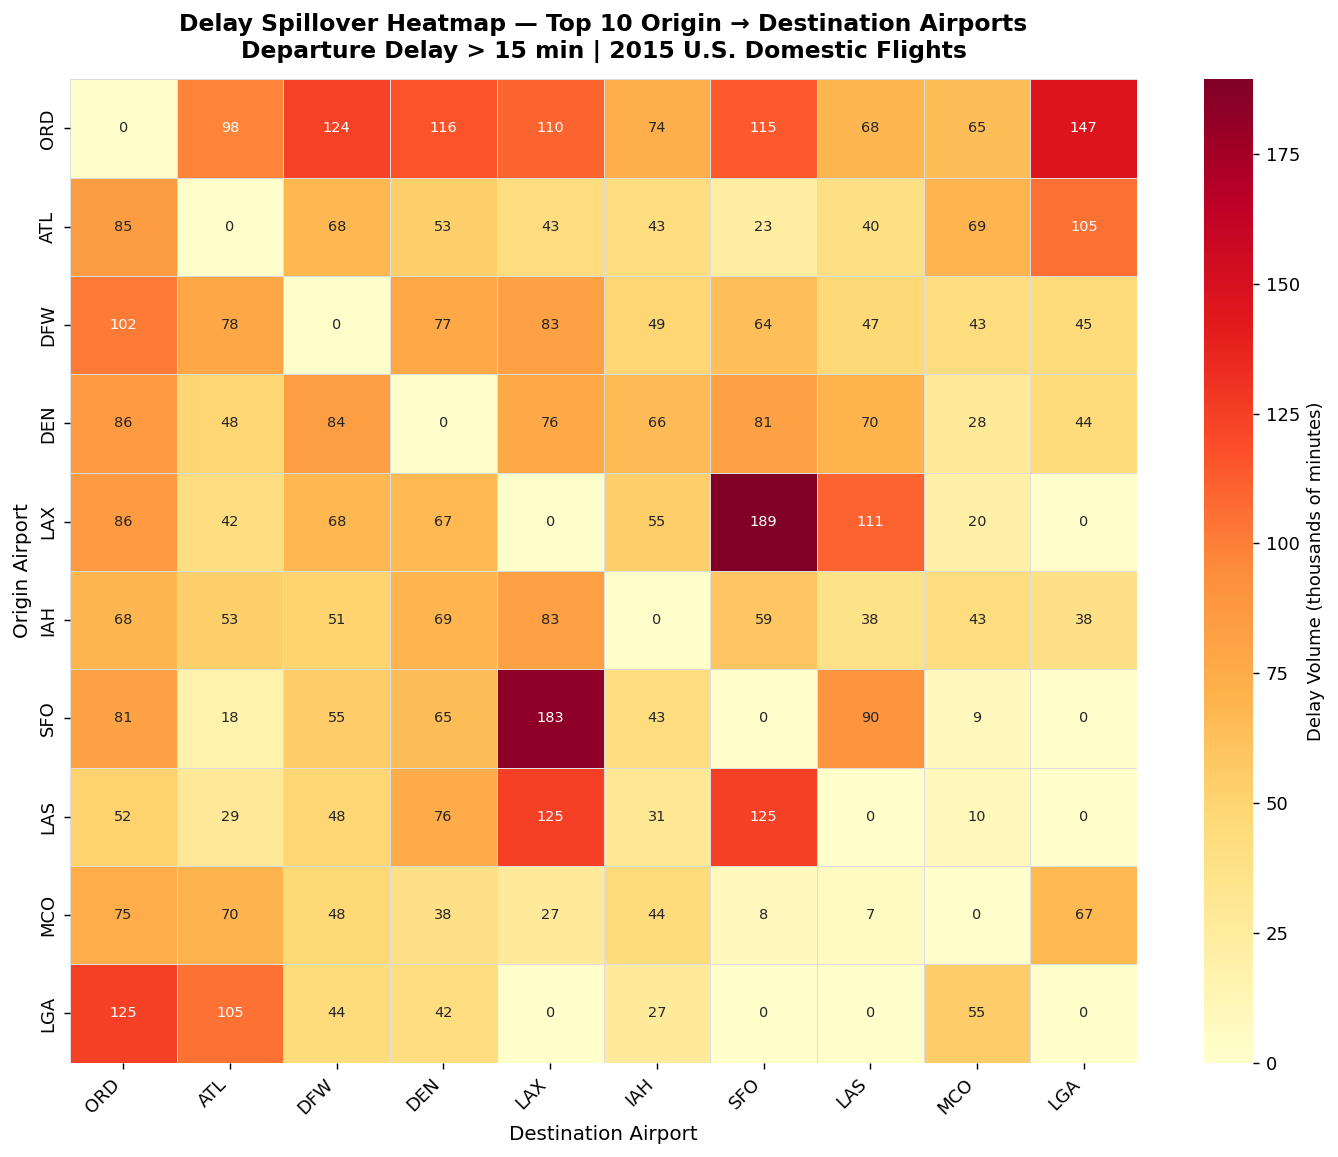

  Saved → delay_heatmap.png


In [ ]:
print("\n🗺️  Visualization 3: Heatmap")

top10_list = strength_series.head(10)["AIRPORT"].tolist()

heatmap_data = (
    route_delay[
        route_delay["ORIGIN_AIRPORT"].isin(top10_list) &
        route_delay["DESTINATION_AIRPORT"].isin(top10_list)
    ]
    .pivot_table(
        index="ORIGIN_AIRPORT",
        columns="DESTINATION_AIRPORT",
        values="DELAY_VOLUME",
        aggfunc="sum",
    )
    .fillna(0)
    / 1e3   # convert to thousands of minutes
)

# Reindex so both axes cover all top10
heatmap_data = heatmap_data.reindex(index=top10_list, columns=top10_list, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#ddd",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    cbar_kws={"label": "Delay Volume (thousands of minutes)"},
)
ax.set_title(
    "Delay Spillover Heatmap — Top 10 Origin → Destination Airports\n"
    "Departure Delay > 15 min | 2015 U.S. Domestic Flights",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Destination Airport", fontsize=11)
ax.set_ylabel("Origin Airport", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("delay_heatmap.png", bbox_inches="tight")
plt.show()
print("  Saved → delay_heatmap.png")

# CELL 8 — Stage 4d: Time-Series — Monthly Delay Trend (Top 5)
# ──────────────────────────────────────────────────────


📈 Visualization 4: Monthly Time Series


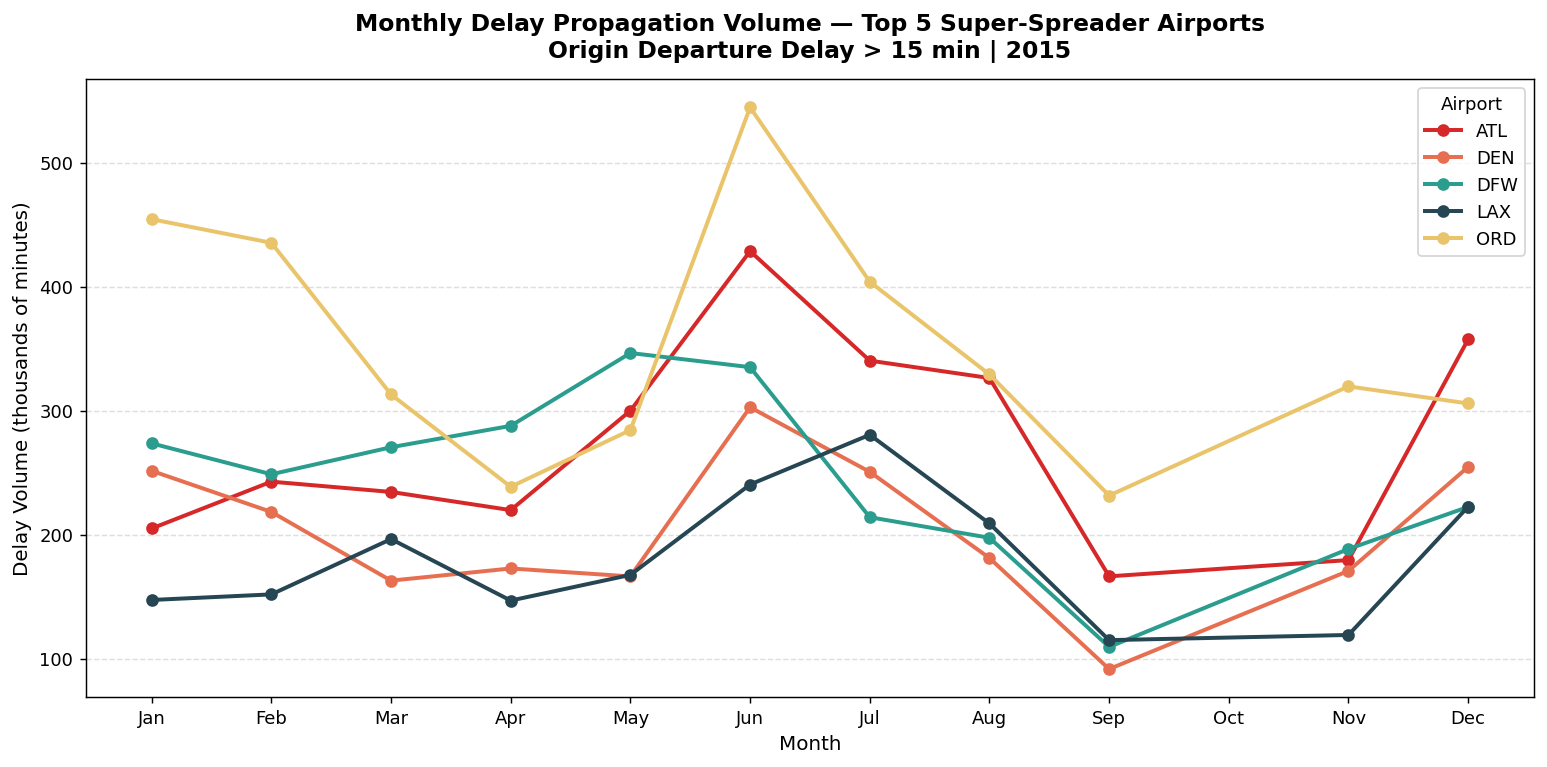

  Saved → delay_timeseries.png


In [ ]:
print("\n📈 Visualization 4: Monthly Time Series")

top5_codes = top5["IATA"].tolist()
monthly = (
    delayed[delayed["ORIGIN_AIRPORT"].isin(top5_codes)]
    .groupby(["MONTH", "ORIGIN_AIRPORT"])["ARRIVAL_DELAY"]
    .sum()
    .reset_index()
    .rename(columns={"ARRIVAL_DELAY": "DELAY_VOLUME"})
)
monthly["DELAY_VOLUME"] /= 1e3   # thousands of minutes

fig, ax = plt.subplots(figsize=(12, 6))
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
colors = ["#D62828", "#E76F51", "#2A9D8F", "#264653", "#E9C46A"]

for (airport, grp), color in zip(monthly.groupby("ORIGIN_AIRPORT"), colors):
    grp_sorted = grp.sort_values("MONTH")
    ax.plot(
        grp_sorted["MONTH"], grp_sorted["DELAY_VOLUME"],
        marker="o", linewidth=2.2, markersize=6,
        color=color, label=airport,
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Delay Volume (thousands of minutes)", fontsize=11)
ax.set_title(
    "Monthly Delay Propagation Volume — Top 5 Super-Spreader Airports\n"
    "Origin Departure Delay > 15 min | 2015",
    fontsize=13, fontweight="bold", pad=12,
)
ax.legend(title="Airport", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("delay_timeseries.png", bbox_inches="tight")
plt.show()
print("  Saved → delay_timeseries.png")

# CELL 9 — Stage 5: Insight Summary
# ──────────────────────────────────────────────────────

In [ ]:
print("\n" + "="*62)
print("  STAGE 5 — FINDINGS & RECOMMENDATIONS")
print("="*62)

print("\n🏆 Top 5 Super-Spreader Airports (2015 U.S. Domestic Flights)")
print("-"*62)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(
        f"  #{rank}  {row['IATA']:4s}  {str(row.get('CITY',''))}, "
        f"{str(row.get('STATE','')):<4s}  →  "
        f"{row['OUT_STRENGTH']/1e6:.2f}M delay-minutes propagated"
    )


  STAGE 5 — FINDINGS & RECOMMENDATIONS

🏆 Top 5 Super-Spreader Airports (2015 U.S. Domestic Flights)
--------------------------------------------------------------
  #1  ORD   Chicago, IL    →  3.87M delay-minutes propagated
  #2  ATL   Atlanta, GA    →  3.01M delay-minutes propagated
  #3  DFW   Dallas-Fort Worth, TX    →  2.70M delay-minutes propagated
  #4  DEN   Denver, CO    →  2.23M delay-minutes propagated
  #5  LAX   Los Angeles, CA    →  2.00M delay-minutes propagated


In [ ]:
print("""
📋 INTERPRETATION
─────────────────
• Weighted Out-Strength Centrality measures the total minutes of
  arrival delay an airport pushes into the rest of the network
  when its own departures are ≥15 min late.

• The top-ranked airports are large hub airports with many
  high-frequency outbound routes. Even moderate per-flight
  delays multiply into millions of downstream delay-minutes
  across the network (the "spillover effect").

• The Time-Series chart shows summer (Jun–Aug) and winter
  (Dec–Jan) as peak delay seasons, aligning with known
  weather and high-traffic patterns.

🛡️ RECOMMENDATIONS
───────────────────
1. Buffer-time policy: FAA should mandate minimum 20-min ground
   buffer between scheduled turns at the top-5 hubs during peak
   months (Jun, Jul, Dec) to absorb local disruptions before
   they cascade downstream.

2. Demand levelling: Airlines should consider shifting non-peak
   connecting traffic away from the top-5 hubs to alternative
   airports (e.g. MDW instead of ORD, DAL instead of DFW)
   during congestion-prone periods.

3. Real-time monitoring: A live dashboard tracking Weighted
   Out-Strength at these five airports on a rolling 6-hour
   window could give air-traffic control early warning of
   impending systemic cascade events.

⚠️ LIMITATIONS
───────────────
• The model attributes delays to the origin airport; in reality,
  rotation delays from upstream legs are under-captured.
• All findings are specific to 2015 traffic patterns and may
  not generalise to current post-pandemic route networks.
""")

print("✅ Full pipeline complete. All charts saved as PNG files.")


📋 INTERPRETATION
─────────────────
• Weighted Out-Strength Centrality measures the total minutes of
  arrival delay an airport pushes into the rest of the network
  when its own departures are ≥15 min late.

• The top-ranked airports are large hub airports with many
  high-frequency outbound routes. Even moderate per-flight
  delays multiply into millions of downstream delay-minutes
  across the network (the "spillover effect").

• The Time-Series chart shows summer (Jun–Aug) and winter
  (Dec–Jan) as peak delay seasons, aligning with known
  weather and high-traffic patterns.

🛡️ RECOMMENDATIONS
───────────────────
1. Buffer-time policy: FAA should mandate minimum 20-min ground
   buffer between scheduled turns at the top-5 hubs during peak
   months (Jun, Jul, Dec) to absorb local disruptions before
   they cascade downstream.

2. Demand levelling: Airlines should consider shifting non-peak
   connecting traffic away from the top-5 hubs to alternative
   airports (e.g. MDW instead o